# 04 — Approximate Time-to-Churn (Survival Analysis)
### SmartTel Retention Intelligence — (Future Work / Experimental Extension)

**Input:** `telco_features_with_personas_latest.parquet` (produced by `03_classification_benchmarking.ipynb`)

> **Status: Future Work.** This module is scoped separately from the core system (Modules 1–3, 6–8), which is complete and deployable without it. It is included here because it extends the churn-risk view from a single point-in-time probability to a *time-aware* one, which is directly useful for scheduling retention outreach, but it rests on an approximation that is stated plainly below and should not be glossed over.

**Scope of this notebook**:
1. Construct the survival dataset (`duration = tenure`, `event = Churn`)
2. Kaplan-Meier curves, overall and stratified by Contract, PaymentMethod, and persona
3. Log-rank tests confirming stratified differences are statistically real
4. Cox Proportional Hazards model — hazard ratios per feature, with the proportional-hazards assumption explicitly checked (not assumed)
5. Random Survival Forest as a non-linear comparison, evaluated against Cox via concordance index (C-index)
6. Per-customer expected time-to-churn, to feed Module 6's CLV estimate
7. Persist outputs, with the approximation caveat carried into the column names and metadata themselves


## What This Module Can and Cannot Claim

**What is legitimate here:** using `tenure` as the survival duration and `Churn` as the event indicator is a standard, textbook-correct setup for right-censored survival analysis, customers who haven't churned are censored at their current tenure; customers who have churned have an observed event time. Kaplan-Meier and Cox models fit to this structure are methodologically valid, not a misuse of the technique.

**What is *not* available, and why this is labeled an approximation:** this is a single cross-sectional extract of the customer base at one point in time, not a tracked cohort observed over calendar time. Concretely, that means:
- There is no way to validate these survival estimates against **actual future churn events** — everything here is fit and evaluated on the same static snapshot (via train/test splitting, which helps, but doesn't substitute for out-of-time validation)
- Hazard ratios reflect associations **within this snapshot's customer mix**; if the underlying customer base or market conditions shift, the fitted hazards may not transfer forward
- Any customer whose tenure is still accumulating at the moment of extraction is right-censored *at that instant* — there is no way to distinguish "about to churn next month" from "will stay for years" among currently-active customers beyond what the model infers from their covariates

These estimates are used **directionally** in this project to rank customers by urgency, and to feed a remaining-tenure estimate into CLV calculation — not as calendar-accurate forecasts of when any individual customer will leave.


## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import date

from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import multivariate_logrank_test
from lifelines.utils import concordance_index

from sksurv.ensemble import RandomSurvivalForest
from sksurv.util import Surv

pd.set_option("display.max_columns", 100)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

FEATURE_STORE_DIR = Path("../data/feature_store")
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


## 2. Load Scored Dataset

In [2]:
df = pd.read_parquet(FEATURE_STORE_DIR / "telco_features_with_personas_latest.parquet")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df[["customerID", "tenure", "Churn", "Contract", "PaymentMethod", "persona_name"]].head(3)


Shape: 7,043 rows x 27 columns


,customerID,tenure,Churn,Contract,PaymentMethod,persona_name
0,7590-VHVEG,1,No,Month-to-month,Electronic check,New & Price-Sensitive
1,5575-GNVDE,34,No,One year,Mailed check,New & Price-Sensitive
2,3668-QPYBK,2,Yes,Month-to-month,Mailed check,New & Price-Sensitive


## 3. Constructing the Survival Dataset

In [3]:
df["duration"] = df["tenure"]
df["event_observed"] = (df["Churn"] == "Yes").astype(int)

zero_duration_count = (df["duration"] == 0).sum()
print(f"Customers with duration == 0: {zero_duration_count}")
print(df.loc[df["duration"] == 0, ["customerID", "duration", "event_observed"]])


Customers with duration == 0: 11
      customerID  duration  event_observed
488   4472-LVYGI         0               0
753   3115-CZMZD         0               0
936   5709-LVOEQ         0               0
1082  4367-NUYAO         0               0
1340  1371-DWPAZ         0               0
3331  7644-OMVMY         0               0
3826  3213-VVOLG         0               0
4380  2520-SGTTA         0               0
5218  2923-ARZLG         0               0
6670  4075-WKNIU         0               0
6754  2775-SEFEE         0               0


These 11 customers have `tenure == 0` and are all censored (`Churn == No`) — brand-new customers observed at the instant of signup. They are kept in the dataset rather than dropped: lifelines handles `duration == 0` correctly, and while these rows contribute essentially no information to the fitted curves (they're "at risk" for zero elapsed time), removing them would be an arbitrary exclusion rather than a principled one.


In [4]:
print(f"Total customers: {len(df):,}")
print(f"Observed events (churned): {df['event_observed'].sum():,} ({df['event_observed'].mean()*100:.1f}%)")
print(f"Censored (still active): {(1 - df['event_observed']).sum():,} ({(1 - df['event_observed'].mean())*100:.1f}%)")


Total customers: 7,043
Observed events (churned): 1,869 (26.5%)
Censored (still active): 5,174 (73.5%)


## 4. Overall Kaplan-Meier Curve

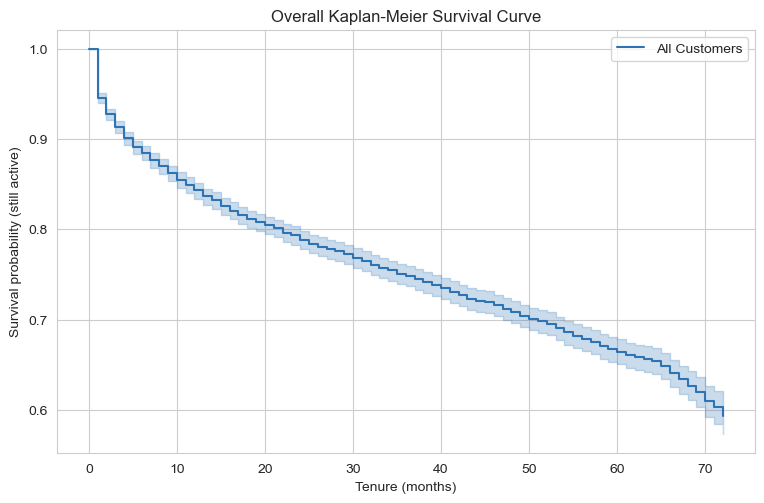

Median survival time: inf


In [5]:
kmf = KaplanMeierFitter()
kmf.fit(durations=df["duration"], event_observed=df["event_observed"], label="All Customers")

fig, ax = plt.subplots(figsize=(9, 5.5))
kmf.plot_survival_function(ax=ax, color="#2E74B5")
ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Survival probability (still active)")
ax.set_title("Overall Kaplan-Meier Survival Curve")
plt.show()

median_survival = kmf.median_survival_time_
print(f"Median survival time: {median_survival}")


If the median shows as `inf`, it means fewer than half the customers in this snapshot have churned by the maximum observed tenure — i.e. survival probability never drops below 0.5 within the data's range, which is expected given the ~26.5% overall churn rate.


## 5. Stratified Kaplan-Meier Curves

### 5.1 By Contract Type

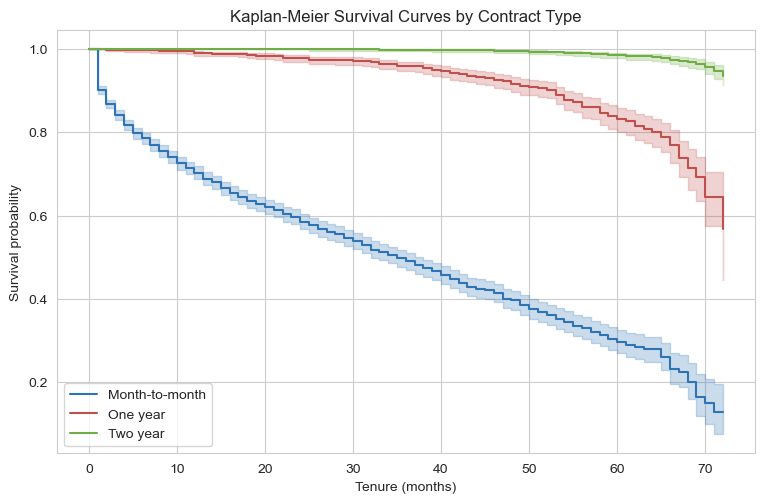

In [6]:
fig, ax = plt.subplots(figsize=(9, 5.5))
colors = ["#2E74B5", "#C0504D", "#70AD47"]

for color, contract in zip(colors, df["Contract"].unique()):
    mask = df["Contract"] == contract
    kmf_c = KaplanMeierFitter()
    kmf_c.fit(df.loc[mask, "duration"], df.loc[mask, "event_observed"], label=contract)
    kmf_c.plot_survival_function(ax=ax, color=color)

ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Survival probability")
ax.set_title("Kaplan-Meier Survival Curves by Contract Type")
plt.show()


In [7]:
logrank_contract = multivariate_logrank_test(df["duration"], df["Contract"], df["event_observed"])
print(f"Log-rank test across Contract groups: statistic={logrank_contract.test_statistic:.2f}, p-value={logrank_contract.p_value:.2e}")


Log-rank test across Contract groups: statistic=2352.87, p-value=0.00e+00


### 5.2 By Payment Method

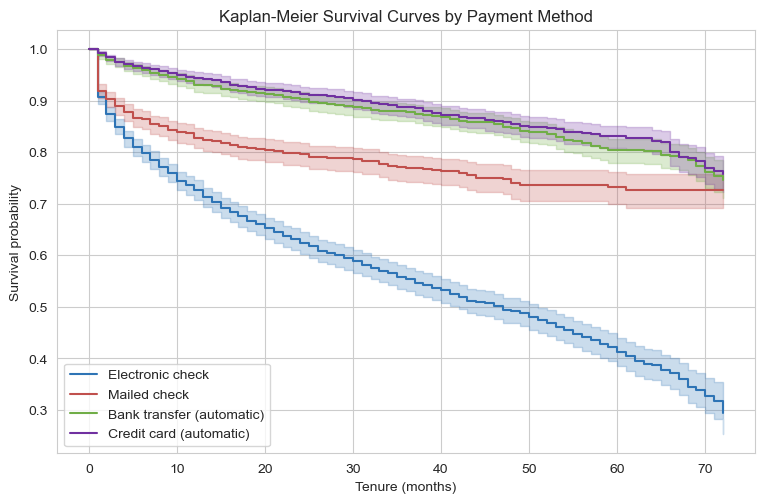

In [8]:
fig, ax = plt.subplots(figsize=(9, 5.5))
colors = ["#2E74B5", "#C0504D", "#70AD47", "#7030A0"]

for color, method in zip(colors, df["PaymentMethod"].unique()):
    mask = df["PaymentMethod"] == method
    kmf_p = KaplanMeierFitter()
    kmf_p.fit(df.loc[mask, "duration"], df.loc[mask, "event_observed"], label=method)
    kmf_p.plot_survival_function(ax=ax, color=color)

ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Survival probability")
ax.set_title("Kaplan-Meier Survival Curves by Payment Method")
plt.show()


In [9]:
logrank_payment = multivariate_logrank_test(df["duration"], df["PaymentMethod"], df["event_observed"])
print(f"Log-rank test across PaymentMethod groups: statistic={logrank_payment.test_statistic:.2f}, p-value={logrank_payment.p_value:.2e}")


Log-rank test across PaymentMethod groups: statistic=865.24, p-value=3.07e-187


### 5.3 By Persona

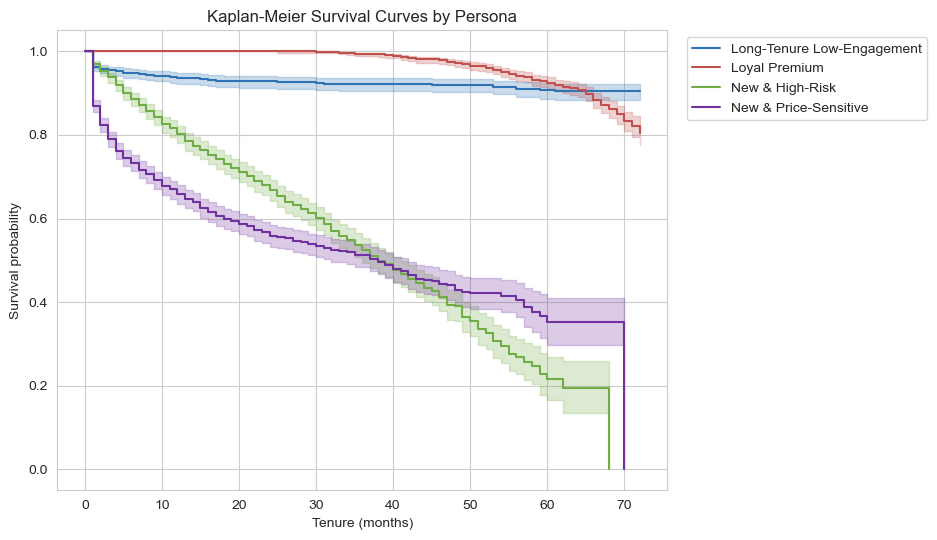

In [10]:
fig, ax = plt.subplots(figsize=(9.5, 5.5))
colors = ["#2E74B5", "#C0504D", "#70AD47", "#7030A0", "#E8A33D", "#4472C4"]

for color, persona in zip(colors, sorted(df["persona_name"].unique())):
    mask = df["persona_name"] == persona
    kmf_pers = KaplanMeierFitter()
    kmf_pers.fit(df.loc[mask, "duration"], df.loc[mask, "event_observed"], label=persona)
    kmf_pers.plot_survival_function(ax=ax, color=color)

ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Survival probability")
ax.set_title("Kaplan-Meier Survival Curves by Persona")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [11]:
logrank_persona = multivariate_logrank_test(df["duration"], df["persona_name"], df["event_observed"])
print(f"Log-rank test across persona groups: statistic={logrank_persona.test_statistic:.2f}, p-value={logrank_persona.p_value:.2e}")


Log-rank test across persona groups: statistic=1942.24, p-value=0.00e+00


All three log-rank tests are expected to return very small p-values (the group sizes here are large, so even modest differences reach significance) — confirming the visual separation between curves is a real, statistically detectable pattern rather than sampling noise. This cross-checks Module 2's finding that persona churn *rates* differ, by showing the *timing* of churn differs too, not just its eventual likelihood.
